In [191]:
import torch
import numpy as np

import matplotlib.pyplot as plt
import random
import einops
from string import ascii_uppercase
from tqdm import tqdm


idx_to_char = {idx: c for idx, c in enumerate(ascii_uppercase)}

In [2]:
# Plotting functions
def heat_map(ten: torch.Tensor, w = 4 , h = 4):
  plt.close()
  fig, ax = plt.subplots()
  im = ax.imshow(ten)
  fig.tight_layout()
  fig.set_size_inches(w, h)
  plt.show()
  return fig, ax

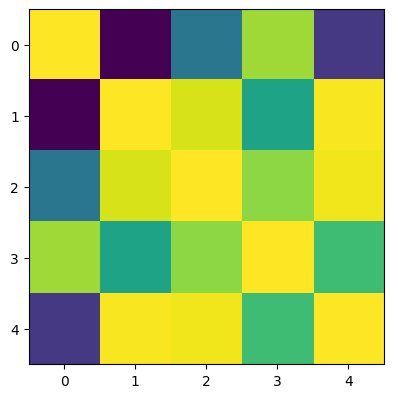

[4, 2]
Input: tensor([0., 0., 1., 0., 1.])
Recovered: tensor([1.3659, 1.9700, 1.9905, 1.7882, 1.9905])
Loss: 1.4210


In [3]:

N_FEATURES = 5
N_DIMS = 2

def get_reconstruction_loss(sparsity=0):
  """
  Get reconstruction loss
  """
  input = torch.zeros((N_FEATURES,))

  rand_idx = random.sample(range(N_FEATURES), k=sparsity)
  print(rand_idx)
  input[rand_idx] = 1

  # F (2x5) @ input (5,) = hidden (2,)
  hidden = input @ F.T

  # F.T (5x2) @ hidden (2, ) = recovered (5, )
  recovered = F.T @ hidden

  loss = (recovered - input).abs().mean()

  print(f"Input: {input}")
  print(f"Recovered: {recovered}")
  print(f"Loss: {loss:.4f}")

  return input, recovered, loss


F = torch.rand((N_DIMS, N_FEATURES))

# normalize
F = F / F.norm(dim=0)

interference = F.T @ F

heat_map(interference)
_ = get_reconstruction_loss(sparsity=2)

What we understand is that this interference is *going* to happen because there are more columns (5) than dimensions (2) so they can't be at 90 deg to each other. So the model has to "make do" and separate them as much as possible, but this brings in interference.

Note that with this `F` matrix, we are not talking about "extracting" features from the original data (say pixels in an image). Here we just speak about how the model "stores" or "encodes" the already extracted features.

Why DO we only let the model store all 5 fetures into 2 numbers? Why not just have 5 numbers to store it in? Then we'd not have to worry about this superposition business at all.

The answer is that this is an incredibly contrived example. If we did the above for *real* networks, we'd quickly run into incredible problems of scale.

For example, let us say there is a million "concepts" or "features" in language like verbs, prononus, cities, non capitals etc etc. Let's say we want to train GPT-3 with this.

- GPT-3 with 175B parameters costs ~$5M to train
- Each layer has 12000 neurons.
- If we matched neurons to features, it would be 100x larger!
- That is 17.5 trillion parameters 🙃

Hence, we decide a big enough model size we can train, give it all the data and all the concepts and pray to the superposition gods that it works out.

So when we ask the model to store 5 features in 2d, it.. does it, but with some trade offs. This trade off is the interference above.

What the heck do we even want to do with these "encodings" aka columns of the matrix? The reason is that, eventually, the model would want to do some form of computation with it. For example if it sees features for "Red" and "Car" with high values then it could safely assume that the incoming image has a "Red car" in it.

The "computation" the model does in teh red car example above is the AND computation. "Red" AND "CAR" = "has a red car"

If the features and dimensions we can store it in were the same dimensioned, we'd have no problems. We could just map each feature to a dimension and call it a day. something like:

```python
F = [
  [1, 0, 0, 0, 0],
  [0, 1, 0, 0, 0],
  [0, 0, 1, 0, 0],
  [0, 0, 0, 1, 0],
  [0, 0, 0, 0, 1],
]
```

Now the interference matrix is all zeros too except diagonals!

But, as above, that quickly gets us into trouble. (There is still some discomfort here for me. I think I am still not quite sure of features, inputs, feature storage and dimensions)


So we'd liek the model to:
- have optimal size
- maintain superposition but still lean useful things
- be able to compute using the above learned things *while being in superposition*


So as a next step, we will see if our model's internal storage mechanism (aka taking 5 features and projecting it to some direction in 2d) is good enough for the AND operation.

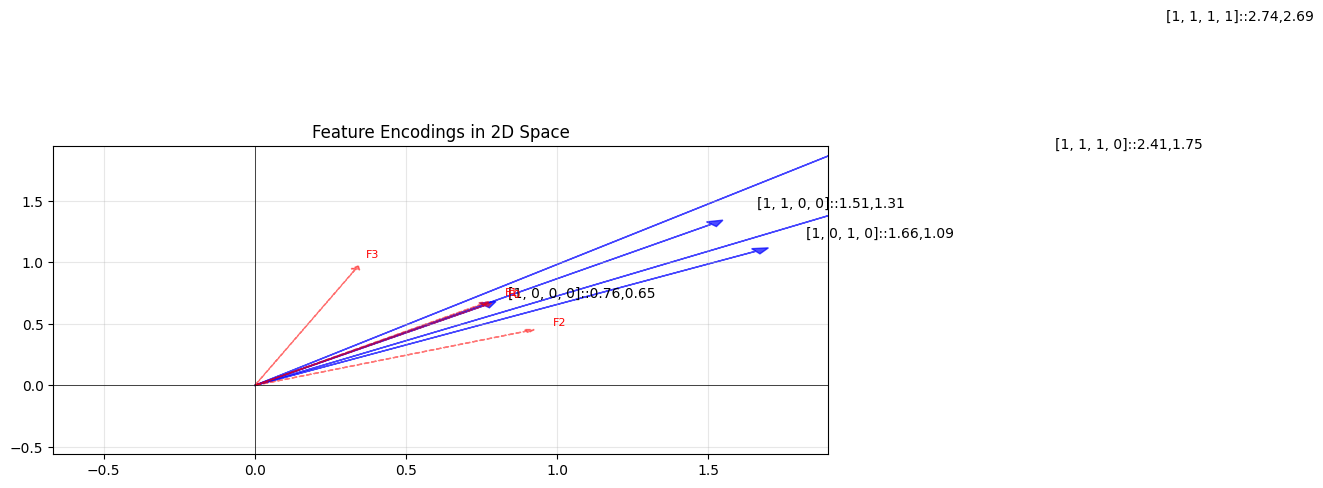

In [17]:
N_DIMS = 2
N_FEATURES = 4

F = torch.rand((N_DIMS, N_FEATURES))
# F = torch.tensor([[0, 1], [1, 0], [-1, 0], [0, -1]]).float().T
# normalise columns
F = F / F.norm(dim = 0)

def encode(input: torch.Tensor | list):
  if type(input) == list:
    input = torch.Tensor(input)

  assert input.shape[0] == N_FEATURES

  # can also call this "hidden"
  encoding = einops.einsum(input, F, "n_features, n_dims n_features -> n_dims")

  return encoding

def plot_encodings(encodings: list[list], F=None):
    plt.figure(figsize=(10, 4))

    # Plot encoded combinations
    for label, encoding in encodings:
        # Arrow from origin to encoding point
        plt.arrow(0, 0, encoding[0], encoding[1],
                 head_width=0.05, head_length=0.05,
                 fc='blue', ec='blue', alpha=0.7)
        # Label at the end
        plt.text(encoding[0]*1.1, encoding[1]*1.1, f"{str(label)}::{','.join([f'{e:.2f}' for e in encoding.tolist()])}", fontsize=10)

    # Optionally plot F columns (individual features)
    if F is not None:
        for i in range(F.shape[1]):
            plt.arrow(0, 0, F[0,i], F[1,i],
                     head_width=0.03, head_length=0.03,
                     fc='red', ec='red', alpha=0.5, linestyle='--')
            plt.text(F[0,i]*1.1, F[1,i]*1.1, f'F{i}', fontsize=8, color='red')

    plt.xlim(F[0, :].min() - 1, F[0, :].max() + 1)
    plt.ylim(F[1, :].min() - 1, F[1, :].max() + 1)
    plt.grid(True, alpha=0.3)
    plt.axhline(y=0, color='k', linewidth=0.5)
    plt.axvline(x=0, color='k', linewidth=0.5)
    plt.title("Feature Encodings in 2D Space")
    plt.show()

# Test it
encodings = [[l, encode(l)] for l in [[1,0,0,0], [1,1,0,0], [1,0,1,0], [1, 1, 1, 0], [1,1,1,1]]]
plot_encodings(encodings, F=F)

Okay soo

When we encode our above inputs which have different "features" on and off ([1, 1, 0, 0] has A and B on),

The "layer" after this one will "see" only the output which is two numbers. It needs to make a decision based on those two numbers.

That layer will have neurons too, and a feature matrix too! In similar fashion to our F matrix which has inputs as 5 dims but only gives out 2 (so each of the rows is a way to "weigh" the incoming inputs, we take the outputs from the two neurons and look at them in 2d. veyr hacky way to merge outputs from two neurons?)

So lets say our next layer into which we feed the output of this one (the 2d vectors we have created), spits out 100 dimensions. So it would have a weght matrix shape [100, 2]... 100 "sets" of 2 weights, each set being how one neuron in our new layer weighs hte input from our original layer.

What we want to test now is whether there is a combination of weights that give us "distinct enough" values, that we can safely say which of the initial values were 1s (aka which features were active) in our original inputs.

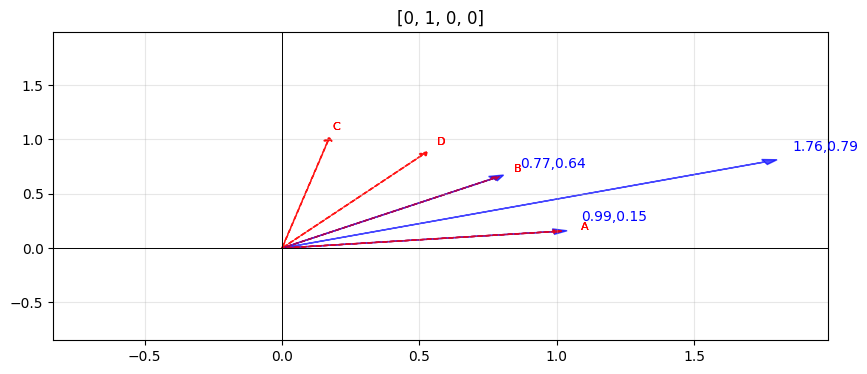

In [68]:
F = torch.rand((N_DIMS, N_FEATURES))
# F = torch.tensor([[0, 1], [1, 0], [-1, 0], [0, -1]]).float().T
# normalise columns
F = F / F.norm(dim = 0)

ab = [1, 1, 0, 0]
just_a = [1, 0, 0, 0]
just_b =[0, 1, 0, 0]

plt.figure(figsize=(10, 4))

for label in [ab, just_a, just_b]:
    # Plot encoded combinations
    encoding = encode(label)
    # Arrow from origin to encoding point
    plt.arrow(0, 0, encoding[0], encoding[1],
                head_width=0.05, head_length=0.05,
                fc='blue', ec='blue', alpha=0.7)
    # Label at the end
    plt.text(encoding[0] + 0.1, encoding[1] + 0.1, f"{','.join([f'{e:.2f}' for e in encoding.tolist()])}", fontsize=10, color="blue")

    # Optionally plot F columns (individual features)
    if F is not None:
        for i in range(F.shape[1]):
            plt.arrow(0, 0, F[0,i], F[1,i],
                        head_width=0.03, head_length=0.03,
                        fc='red', ec='red', alpha=0.5, linestyle='--')
            plt.text(F[0,i]*1.1, F[1,i]*1.1, f'{idx_to_char[i]}', fontsize=8, color='red')

    plt.xlim(F[0, :].min() - 1, F[0, :].max() + 1)
    plt.ylim(F[1, :].min() - 1, F[1, :].max() + 1)
    plt.grid(True, alpha=0.3)
    plt.axhline(y=0, color='k', linewidth=0.5)
    plt.axvline(x=0, color='k', linewidth=0.5)
    plt.title(f"{label}")

plt.show()


think of these encodings as neuron activations.


now that we have the activations, in the next layer, we want to detect using some weight matrix which features were active. (thijnk of this as the weight matrix of the next layer)
SO going forward, our knowledge is limits to encode(ab), encode(just_a), encode(just_b)

let us think of hte next layer as a "classifier"
We want this classifier to tell us whether BOTH A and B are active or not
So we want it to give us a high value for encode(ab), and a low value for encode(a), and encode(b)

all encodings are of the type [a1, a2] (a for activation here), and the weights of our classifier layer could be [w1, w2]
so calculating a1 * w1 + a2 * w2.
notice that this is just hte dot product of the two vectors.
so, another defition of our classifier: we want to choose a vector [w1, w2] such that it gives a high dot product with encode(ab), and a low one with encode(a) and encode(b)

let us think at a micro level about dot products
the dot product of a vector is highest when it is with itself (assuming norms is 1)
so if we take the weights to be aligned with the encoding of ab (w_ab = encode(ab) / encode(ab).norm()), we would get a high dot product with the ab vector!

let us plot how the dot products look like for a few hundred random F matrices, when we align the w of our classifier to the ab encoding. We will plot these things:
- dot product with encodings of a, b, and ab
- the angle between a and b for that iteration

100%|██████████| 10000/10000 [00:01<00:00, 8763.41it/s]


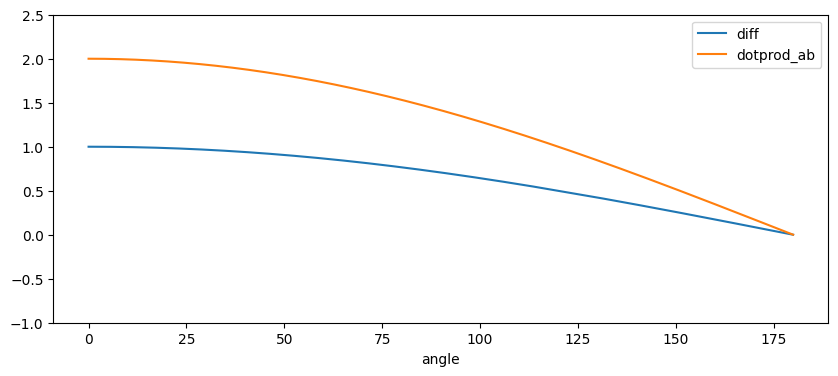

In [ ]:
N_ITERATIONS = 10000

# list of dot products. each item is a list of dot products with encodings of a, b and ab and the last value is the angle between a and b
data: list[dict] = []

for i in tqdm(range(N_ITERATIONS)):
    # we want to allow -1 to 1 here (for full quadrant coverage)
    F = -1 + 2 * torch.rand((N_DIMS, N_FEATURES))
    
    # normalise columns
    F = F / F.norm(dim = 0)

    # make the weight matrix of our classifier the normalised encoding of ab
    w_classifier = encode(ab) / encode(ab).norm()

    # find dot products of this with the encodings of a, b and ab above
    dp = [torch.dot(encode(input), w_classifier) for input in [just_a, just_b, ab]]

    # now we find the angle between a and b (these are columns of F)
    # abs to keep it between 0 and 180
    angle = torch.acos(torch.dot(F[:, 0], F[:, 1])) * 180 / torch.pi
    

    data.append({
        "dot_a": dp[0],
        "dot_b": dp[1],
        "dot_ab": dp[2],
        "angle": angle
    })

# sort the data by angle
data.sort(key=lambda d: d["angle"])

# note that the dot product of ab with a and b is the same because it bisects a and b, and a and b have been given unit norms.
line_dot_a = np.array([d["dot_a"].item() for d in data])
line_dot_ab = np.array([d["dot_ab"].item() for d in data])
angle = np.array([d["angle"].item() for d in data])
diff = np.array([(d["dot_ab"] - d["dot_a"]).item() for d in data])

# plot these four with angle as the x axis
plt.figure(figsize=(10, 4))
plt.plot(angle, diff, label="diff")
plt.plot(angle, line_dot_ab, label="dotprod_ab")
plt.xlabel("angle")

plt.ylim(-1, 2.5)

# plt.text(x = angle[-1], y = diff[-1], s=f"{diff[-1]:.2f}")
# plt.text(x = angle[-1], y = line_dot_ab[-1], s=f"{line_dot_ab[-1]:.2f}")

plt.legend()
plt.show()

Hmm. weird lol.

So my expectation was:
lower angle between a's and b's encodings -> ab's vector is increasingly aligned with both a individually and b individually -> very hard to distinguish if "am i getting ab or just a or just b" because the vectors are the same direction

similarly:
lower angle between a's and b's encodings -> ab's vector has a large angular difference from both a individually and b individually -> easy to distinguish if "am i getting ab or just a or just b" because the vectors are very different

i had assumed that this would translate into "higher difference in dot product between ab's encoding vs a's and b's encodings individually" when a and b are NOT aligned, vs when they are.

but, that is not how dot products work lol. so the difference is actually HIGH when a and b are hyper aligned (because cos 0 is 1. duh.)

-> So if a = v and b also same vector v
then
encoding a = v
encoding b = v
encoding ab = v + v = 2 * v

we choose w = 2 * v / norm(encoding ab) = v

w dot encoding a = v.v = 1
w dot encoding ab = v.2v = 2
difference when parallel = 1
ratio = 1 / 2

-> for a = v and b = w (orthogonal so v.w = 0)
encoding a = v
encoding b = w
encoding ab = v + w

norm(v + w) = sqrt((v+w).(v+w)) = sqrt(v.v + w.w) = √2

we choose `w = (v+w) / norm(v + w) = (v + w) / √2`

w dot encoding a = ((v + w) . v) / √2 = 1 / √2
w dot encoding ab = (v + w) . (v + w) / √2 = 2 / √2 = √2
difference when parallel = √2 - 1/√2 = 1 / √2 = 0.707
ratio = 1 / 2 (same!!)


So, this hypothesis was a failure that "maybe there's a higher difference at 90 deg".

But what we set out to prove was that higher angle between A and B should cause the next layer to be able to tell easily. I guess the layer isn't "telling" based on a simple difference metric.

For now, let us say that this means that encode(ab) is NOT a good way to tell apart just a, just b vs a AND b!! This is a little non intuitive. 

---

Let us then try another experiment:

We need to find a w that maximises this equation:
w.enc(a) - w.enc(ab) OR w.enc(ab) - w.enc(b)

If we want to make this problem harder, we will maximise the smaller of the two!
maximise: `min(w.enc(a) - w.enc(ab), w.enc(ab) - w.enc(b))`

How?? Backprop lol

100%|██████████| 2000/2000 [00:00<00:00, 2598.06it/s]


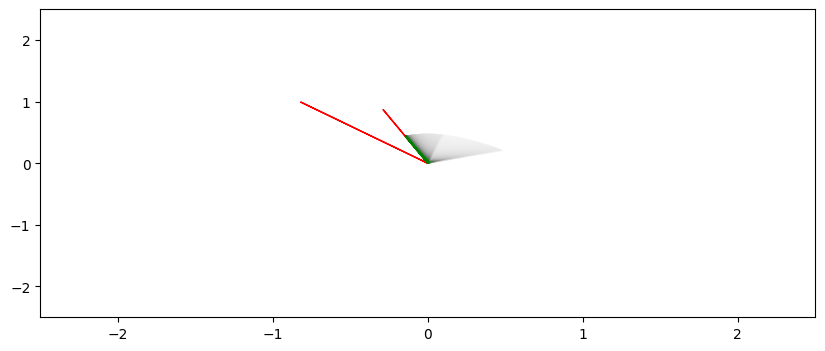

In [ ]:
eps = 1e-8

RADIANS_TO_DEGREES = 180 / torch.pi


def calc_angle(t1, t2, radians=False):
    return (
        torch.acos(torch.dot(t1, t2) / (torch.norm(t1) * torch.norm(t2)))
        * (1 if radians else RADIANS_TO_DEGREES)
    ).item()


def run_exp(NUM_STEPS=2000, plot=False, show_progress=False, start_mid=False):
    if not start_mid:
        # start with random w
        w = torch.rand((N_DIMS,), requires_grad=True)

    enc_a = encode(just_a)
    enc_b = encode(just_b)

    if start_mid:
        # start with w in between enc a and enc b
        w_init = (enc_a + enc_b) / 2
        w_init = w_init + 0.1 * torch.randn_like(w_init)  # Small noise
        w = torch.tensor(w_init, requires_grad=True)

    optimiser = torch.optim.AdamW([w])

    if plot:
        plt.figure(figsize=(10, 4))
        plt.ylim(-2.5, 2.5)
        plt.xlim(-2.5, 2.5)
        plt.arrow(0, 0, enc_a[0].item(), enc_a[1].item(), color="red")
        plt.arrow(0, 0, enc_b[0].item(), enc_b[1].item(), color="red")

    for i in tqdm(range(NUM_STEPS), disable=(not show_progress)):
        optimiser.zero_grad()

        # normalise
        w_normed = w / (w.norm() + eps)
        diff_a = torch.dot(w_normed, encode(ab)) - torch.dot(w_normed, enc_a)
        diff_b = torch.dot(w_normed, encode(ab)) - torch.dot(w_normed, enc_b)

        # we want to maximise this loss so make it negative
        loss = -torch.min(diff_a, diff_b)

        loss.backward()

        optimiser.step()

        if plot:
            plt.arrow(0, 0, w[0].item(), w[1].item(), color="green", alpha=0.005)

    if plot:
        plt.arrow(0, 0, w[0].item(), w[1].item(), color="green")

    return (
        w.detach().numpy(),
        enc_a.detach().numpy(),
        enc_b.detach().numpy(),
        calc_angle(enc_a, enc_b),
        calc_angle(w, enc_a),
        calc_angle(w, enc_b),
    )


F = torch.rand((N_DIMS, N_FEATURES))
F = -1 + 2 * F / F.norm(dim=0)
_ = run_exp(plot=True, show_progress=True)

everytime we run the above, we seem to end up at ... strange Ws. sometimes it is within the "cone" of encodings, sometimes it is outside. it *seems* like when those two are v close to each other it ends up outside (which would make sense. close together and being within cone is confusing), but when the angle is higher, it is okay to be inside the cone somewhere.

Let us run this many times, and record the w and the encodings. Then plot those.

In [454]:
N_ITERATIONS = 200

# list of [w, enc_a, enc_b] for a particular iteration of the experiment
start_mid_results = []
start_random_results = []

for i in tqdm(range(N_ITERATIONS)):
    F = torch.rand((N_DIMS, N_FEATURES))
    F = -1 + 2 * F / F.norm(dim=0)
    w, enc_a, enc_b, ab_angle, w_a_angle, w_b_angle = run_exp(start_mid=True)
    start_mid_results.append({
        "w": w,
        "enc_a": enc_a,
        "enc_b": enc_b,
        "ab_angle": ab_angle,
        "w_a_angle": w_a_angle,
        "w_b_angle": w_b_angle
    })


    F = torch.rand((N_DIMS, N_FEATURES))
    F = -1 + 2 * F / F.norm(dim=0)
    w, enc_a, enc_b, ab_angle, w_a_angle, w_b_angle = run_exp(start_mid=False)
    start_random_results.append({
        "w": w,
        "enc_a": enc_a,
        "enc_b": enc_b,
        "ab_angle": ab_angle,
        "w_a_angle": w_a_angle,
        "w_b_angle": w_b_angle
    })
    

  0%|          | 0/200 [00:00<?, ?it/s]/var/folders/_2/f55vw7nn6yjbtmn634wyrh3r0000gn/T/ipykernel_88808/174166800.py:25: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  w = torch.tensor(w_init, requires_grad=True)
100%|██████████| 200/200 [01:56<00:00,  1.72it/s]


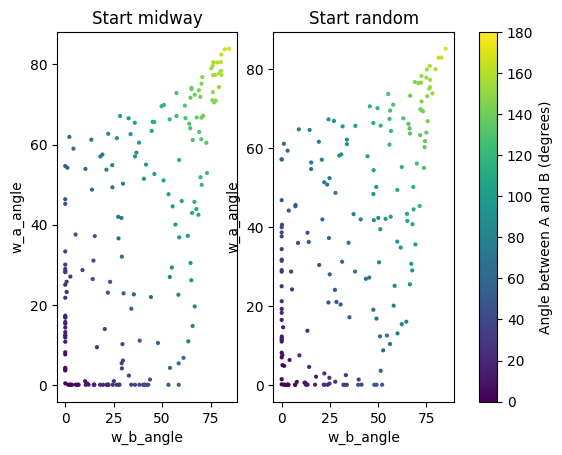

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2)

vmin, vmax = 0, 180
cmap = "viridis"

scatter1 = ax1.scatter(
    x=[d["w_b_angle"] for d in start_mid_results],
    y=[d["w_a_angle"] for d in start_mid_results],
    c=[d["ab_angle"] for d in start_mid_results],
    s=4,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
)
ax1.set_xlabel("w_b_angle")
ax1.set_ylabel("w_a_angle")
ax1.set_title("Start midway")

scatter2 = ax2.scatter(
    x=[d["w_b_angle"] for d in start_random_results],
    y=[d["w_a_angle"] for d in start_random_results],
    c=[d["ab_angle"] for d in start_random_results],
    s=4,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
)
ax2.set_xlabel("w_b_angle")
ax2.set_ylabel("w_a_angle")
ax2.set_title("Start random")

# Add a single colorbar for both plots
fig.colorbar(scatter2, ax=[ax1, ax2], label='Angle between A and B (degrees)')
plt.show()